# MCTNet — Entraînement SANS Covariables
## Arkansas · California
**Wang et al., 2024 — Modèle de base (MCTNet original)**

Ce notebook entraîne **MCTNet** (sans branche covariables) sur Arkansas et California,
puis affiche les courbes d'apprentissage, matrices de confusion et tableau récapitulatif.

## CELLULE 0 — Montage Drive & vérification GPU

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
print('GPU disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))

import os, sys

# ── Modifiez ces chemins ──────────────────────────────────────────────────────
NPY_DIR  = '/content/drive/MyDrive/GEE_CropMapping_2/data_train'
CODE_DIR = '/content/drive/MyDrive/model_data/model'
# ─────────────────────────────────────────────────────────────────────────────

sys.path.append(CODE_DIR)

print('\nVérification des fichiers .npy (input1, input2, labels) :')
for region in ['Arkansas', 'California']:
    for split in ['train', 'val', 'test']:
        for suffix in ['input1', 'input2', 'labels']:
            f = f'{NPY_DIR}/{region}_{split}_{suffix}.npy'
            status = '\u2714' if os.path.exists(f) else '\u2718 MANQUANT'
            print(f'  {status}  {region}_{split}_{suffix}.npy')

Mounted at /content/drive
GPU disponible : False

Vérification des fichiers .npy (input1, input2, labels) :
  ✔  Arkansas_train_input1.npy
  ✔  Arkansas_train_input2.npy
  ✔  Arkansas_train_labels.npy
  ✔  Arkansas_val_input1.npy
  ✔  Arkansas_val_input2.npy
  ✔  Arkansas_val_labels.npy
  ✔  Arkansas_test_input1.npy
  ✔  Arkansas_test_input2.npy
  ✔  Arkansas_test_labels.npy
  ✔  California_train_input1.npy
  ✔  California_train_input2.npy
  ✔  California_train_labels.npy
  ✔  California_val_input1.npy
  ✔  California_val_input2.npy
  ✔  California_val_labels.npy
  ✔  California_test_input1.npy
  ✔  California_test_input2.npy
  ✔  California_test_labels.npy


## Imports

In [4]:
import os
import time
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

print('PyTorch :', torch.__version__)
print('Device  :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cpu
Device  : cpu


## Architecture MCTNet (sans covariables)

In [5]:
def sinusoidal_pe(seq_len: int, d_model: int, device=None) -> torch.Tensor:
    pe = torch.zeros(seq_len, d_model, device=device)
    position = torch.arange(0, seq_len, dtype=torch.float, device=device).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float, device=device)
        * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[: d_model // 2])
    return pe


class ECA(nn.Module):
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        t = int(abs(math.log2(channels) / gamma + b / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1).unsqueeze(1)
        y = self.sigmoid(self.conv(y)).squeeze(1).unsqueeze(-1)
        return x * y.expand_as(x)


class ALPE(nn.Module):
    def __init__(self, channels: int, seq_len: int, kernel_size: int = 3):
        super().__init__()
        pe = sinusoidal_pe(seq_len, channels)
        self.register_buffer('pe', pe)
        padding   = kernel_size // 2
        self.conv = nn.Conv1d(channels, channels, kernel_size=kernel_size,
                              padding=padding, bias=False)
        self.bn   = nn.BatchNorm1d(channels)
        self.eca  = ECA(channels)

    def forward(self, x, mask):
        mask_bc   = mask.unsqueeze(1).float()
        pe_bct    = self.pe.T.unsqueeze(0)
        masked_pe = pe_bct * mask_bc
        out = F.relu(self.bn(self.conv(masked_pe)))
        out = self.eca(out)
        return x + out


class TransformerSubModule(nn.Module):
    def __init__(self, channels, seq_len, n_head=5,
                 use_alpe=False, kernel_size=3, dropout=0.1):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(channels, seq_len, kernel_size)
        self.attn  = nn.MultiheadAttention(embed_dim=channels, num_heads=n_head,
                                            dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(channels)
        self.ffn   = nn.Sequential(
            nn.Linear(channels, 4 * channels),  # ✅ 4x standard
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * channels, channels),
            nn.Dropout(dropout),
        )
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x, mask=None):
        if self.use_alpe:
            x = self.alpe(x, mask)
        x_t = x.permute(0, 2, 1)                        # (N, T, C)

        # ✅ Add & Norm conforme Fig 4 du paper
        attn_out, _ = self.attn(x_t, x_t, x_t)
        x_t = self.norm1(x_t + attn_out)                # Add & Norm 1
        x_t = self.norm2(x_t + self.ffn(x_t))           # Add & Norm 2

        return x_t.permute(0, 2, 1)                     # (N, C, T)


class CNNSubModule(nn.Module):
    def __init__(self, in_channels, kernel_size=3):
        super().__init__()
        p = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, in_channels,
                               kernel_size=kernel_size, padding=p, bias=False)
        self.bn1   = nn.BatchNorm1d(in_channels)
        self.conv2 = nn.Conv1d(in_channels, in_channels,
                               kernel_size=kernel_size, padding=p, bias=False)
        self.bn2   = nn.BatchNorm1d(in_channels)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn2(self.conv2(self.bn1(self.conv1(x)))) + x)


class CTFusion(nn.Module):
    """Stage 1 et 2 : avec MaxPool(stride=2)"""
    def __init__(self, in_channels, seq_len, n_head=5,
                 kernel_size=3, use_alpe=False, dropout=0.1):
        super().__init__()
        self.cnn         = CNNSubModule(in_channels, kernel_size)
        self.transformer = TransformerSubModule(in_channels, seq_len,
                                                n_head, use_alpe,
                                                kernel_size, dropout)
        self.pool        = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        out = torch.cat([self.cnn(x), self.transformer(x, mask)], dim=1)
        return self.pool(out)


class CTFusionFinal(nn.Module):
    """Stage 3 : avec Global Max Pooling (conforme Fig 3 paper)"""
    def __init__(self, in_channels, seq_len, n_head=5,
                 kernel_size=3, dropout=0.1):
        super().__init__()
        self.cnn         = CNNSubModule(in_channels, kernel_size)
        self.transformer = TransformerSubModule(in_channels, seq_len,
                                                n_head, False,
                                                kernel_size, dropout)

    def forward(self, x, mask=None):
        out = torch.cat([self.cnn(x), self.transformer(x, mask)], dim=1)
        return out.max(dim=2).values  # ✅ Global Max Pooling → (N, 80)


class MCTNet(nn.Module):
    """MCTNet original — Wang et al., 2024"""
    def __init__(self, n_classes, n_head=5, kernel_size=3, dropout=0.1):
        super().__init__()
        self.stage1     = CTFusion(10, 36, n_head, kernel_size,
                                   use_alpe=True,  dropout=dropout)
        self.stage2     = CTFusion(20, 18, n_head, kernel_size,
                                   use_alpe=False, dropout=dropout)
        self.stage3     = CTFusionFinal(40, 9, n_head, kernel_size,
                                        dropout=dropout)
        self.classifier = nn.Linear(80, n_classes)

    def forward(self, x, mask):
        # ✅ PAS de permute — données déjà en (N, 10, 36)
        out = self.stage1(x, mask)  # (N, 20, 18)
        out = self.stage2(out)      # (N, 40, 9)
        out = self.stage3(out)      # (N, 80)
        return self.classifier(out) # (N, n_classes)

# ✅ Test avec le bon format (N, 10, 36)
print('Test rapide...')
m = MCTNet(n_classes=5)
dummy_x    = torch.randn(4, 10, 36)  # ← format réel des données
dummy_mask = torch.ones(4, 36)
out = m(dummy_x, dummy_mask)
print(f'  Input : {dummy_x.shape} | Output : {out.shape}  ✓')

print('Architecture MCTNet corrigée définie.')
print(f'Test rapide...')
# ✅ Garde uniquement ce test
print('Test rapide...')
m = MCTNet(n_classes=5)
dummy_x    = torch.randn(4, 10, 36)   # ← format correct (N, bands, time)
dummy_mask = torch.ones(4, 36)
out = m(dummy_x, dummy_mask)
print(f'  Input : {dummy_x.shape} | Output : {out.shape}  ✓')

# ❌ Supprime ce bloc — format inversé incorrect
# dummy_x = torch.randn(4, 36, 10)
# out = m(dummy_x, dummy_mask)

Test rapide...
  Input : torch.Size([4, 10, 36]) | Output : torch.Size([4, 5])  ✓
Architecture MCTNet corrigée définie.
Test rapide...
Test rapide...
  Input : torch.Size([4, 10, 36]) | Output : torch.Size([4, 5])  ✓


## Configuration globale

In [6]:
CONFIG = {
    'lr':          0.001,
    'batch_size':  32,
    'epochs':      200,
    'n_head':      5,
    'kernel_size': 3,
    'dropout':     0.1,
    'print_every': 10,
}

N_CLASSES = {'Arkansas': 5, 'California': 6}

CLASS_NAMES = {
    'Arkansas':   ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others'],
    'California': ['Rice', 'Alfalfa', 'Grapes', 'Almonds', 'Pistachios', 'Others'],
}

DATA_DIR = NPY_DIR

all_results   = {}
all_histories = {}
all_models    = {}

print('Configuration chargee.')
print(f'Regions : {list(N_CLASSES.keys())}')

Configuration chargee.
Regions : ['Arkansas', 'California']


## Dataset sans covariables

In [7]:
class CropDataset(Dataset):
    """
    Charge (input1=S2, input2=mask, labels) depuis des fichiers .npy.
    Aucune covariable n'est chargee.
    """
    def __init__(self, data_dir: str, region: str, split: str):
        prefix    = os.path.join(data_dir, f'{region}_{split}')
        self.X    = torch.from_numpy(np.load(f'{prefix}_input1.npy')).float()
        self.mask = torch.from_numpy(np.load(f'{prefix}_input2.npy')).float()
        self.y    = torch.from_numpy(np.load(f'{prefix}_labels.npy')).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

## Fonctions d'entraînement et d'évaluation

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X, mask), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            logits = model(X, mask)
            total_loss += criterion(logits, y).item() * len(y)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        cohen_kappa_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
    )


def run_training(region: str, data_dir: str, config: dict, device: torch.device):
    n_classes = N_CLASSES[region]
    save_path = f'best_MCTNet_{region}_no_covars.pth'

    print('=' * 60)
    print(f'  MCTNet — {region}  ({n_classes} classes)')
    print('=' * 60)

    train_set    = CropDataset(data_dir, region, 'train')
    val_set      = CropDataset(data_dir, region, 'val')
    test_set     = CropDataset(data_dir, region, 'test')
    train_loader = DataLoader(train_set, batch_size=config['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=config['batch_size'], shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=config['batch_size'], shuffle=False)
    print(f'  Données : {len(train_set)} train | {len(val_set)} val | {len(test_set)} test')

    model = MCTNet(
        n_classes=n_classes,
        n_head=config['n_head'],
        kernel_size=config['kernel_size'],
        dropout=config['dropout'],
    ).to(device)
    print(f'  Paramètres : {sum(p.numel() for p in model.parameters()):,}')

    criterion = nn.CrossEntropyLoss()

    # ✅ weight_decay pour régularisation L2
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config.get('weight_decay', 1e-4)
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10,
    )

    history = {'train_loss': [], 'val_loss': [],
               'val_oa': [], 'val_kappa': [], 'val_f1': []}
    best_f1, best_epoch = 0.0, 0

    # ✅ Early Stopping
    es_patience = config.get('es_patience', 30)
    es_counter  = 0
    best_val_loss = float('inf')

    for epoch in range(1, config['epochs'] + 1):
        train_loss                          = train_one_epoch(model, train_loader,
                                                              criterion, optimizer, device)
        val_loss, val_oa, val_kappa, val_f1 = evaluate(model, val_loader,
                                                        criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        # Sauvegarde meilleur modèle
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)

        # Early stopping sur val_loss
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            es_counter    = 0
        else:
            es_counter += 1
            if es_counter >= es_patience:
                print(f'  Early stopping à l\'epoch {epoch} '
                      f'(best epoch={best_epoch}, best F1={best_f1:.4f})')
                break

        if epoch % config.get('print_every', 10) == 0:
            print(f'  Ep {epoch:3d} | train={train_loss:.4f} '
                  f'val={val_loss:.4f} OA={val_oa:.4f} F1={val_f1:.4f}')

    # Évaluation finale sur test
    model.load_state_dict(torch.load(save_path, map_location=device))
    _, test_oa, test_kappa, test_f1 = evaluate(model, test_loader, criterion, device)
    print(f'\n  ✅ Test — OA={test_oa:.4f} | Kappa={test_kappa:.4f} | F1={test_f1:.4f}')
    print(f'  Meilleur epoch : {best_epoch} | Meilleur F1 val : {best_f1:.4f}')

    return history, {'OA': test_oa, 'Kappa': test_kappa, 'F1': test_f1}, save_path

## Fonctions de visualisation

In [9]:
def plot_curves(all_histories: dict):
    regions = list(all_histories.keys())
    n = len(regions)
    fig, axes = plt.subplots(n, 4, figsize=(22, 5 * n), facecolor='#F8F9FA')
    if n == 1:
        axes = [axes]
    fig.suptitle("Courbes d'apprentissage - MCTNet (sans covariables)",
                 fontsize=15, fontweight='bold', y=1.01)
    COLORS = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']

    for row, region in enumerate(regions):
        hist = all_histories[region]
        ep   = range(1, len(hist['train_loss']) + 1)

        axes[row][0].plot(ep, hist['train_loss'], color=COLORS[0], label='Train')
        axes[row][0].plot(ep, hist['val_loss'],   color=COLORS[1], label='Val', linestyle='--')
        axes[row][0].set_title(f'{region} - Loss')
        axes[row][0].legend(); axes[row][0].grid(alpha=0.3)

        for col, (key, color, label) in enumerate(
            [('val_oa', COLORS[2], 'OA'), ('val_kappa', COLORS[3], 'Kappa'),
             ('val_f1', COLORS[4], 'F1 Macro')], start=1):
            best = max(hist[key])
            axes[row][col].plot(ep, hist[key], color=color)
            axes[row][col].axhline(best, color='red', linestyle='--', lw=1,
                                   label=f'Best={best:.4f}')
            axes[row][col].set_title(f'{region} - {label} (Val)')
            axes[row][col].set_ylim(0, 1)
            axes[row][col].legend(fontsize=8); axes[row][col].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('curves_no_covars.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegarde : curves_no_covars.png')


def plot_confusion(all_models: dict, all_results: dict, device: torch.device):
    regions = list(all_models.keys())
    fig, axes = plt.subplots(1, len(regions),
                              figsize=(8 * len(regions) + 1, 7), facecolor='#F8F9FA')
    if len(regions) == 1:
        axes = [axes]
    fig.suptitle('Matrices de confusion - MCTNet (sans covariables)',
                 fontsize=14, fontweight='bold')

    for ax, region in zip(axes, regions):
        mdl = MCTNet(n_classes=N_CLASSES[region],
                     n_head=CONFIG['n_head'],
                     kernel_size=CONFIG['kernel_size'],
                     dropout=CONFIG['dropout']).to(device)
        mdl.load_state_dict(torch.load(all_models[region], map_location=device))
        mdl.eval()

        test_ld = DataLoader(CropDataset(DATA_DIR, region, 'test'),
                             batch_size=CONFIG['batch_size'], shuffle=False)
        preds, labels = [], []
        with torch.no_grad():
            for X, mask, y in test_ld:
                logits = mdl(X.to(device), mask.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                labels.extend(y.numpy())

        cm  = confusion_matrix(labels, preds, normalize='true')
        res = all_results[region]
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES[region]).plot(
            ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
        ax.set_title(f'{region}\nOA={res["OA"]:.4f}  k={res["Kappa"]:.4f}  F1={res["F1"]:.4f}',
                     fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('confusion_no_covars.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sauvegarde : confusion_no_covars.png')


def print_results_table(all_results: dict):
    print('\n' + '=' * 52)
    print('  RESULTATS -- MCTNet SANS COVARIABLES')
    print('=' * 52)
    print(f'  {"Region":<14} {"OA":>9} {"Kappa":>9} {"F1":>9}')
    print('  ' + '-' * 44)
    for region in ['Arkansas', 'California']:
        if region not in all_results:
            continue
        r = all_results[region]
        print(f'  {region:<14} {r["OA"]:>9.4f} {r["Kappa"]:>9.4f} {r["F1"]:>9.4f}')
    print('=' * 52)

## BOUCLE PRINCIPALE — Entraînement Arkansas & California

In [10]:
REGIONS  = ['Arkansas', 'California']
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
t_global = time.time()

for REGION in REGIONS:
    print(f'\n>>>  {REGION}  [SANS COVARIABLES]  <<<')
    history, test_metrics, save_path = run_training(
        region=REGION, data_dir=DATA_DIR, config=CONFIG, device=device
    )
    all_histories[REGION] = history
    all_results[REGION]   = test_metrics
    all_models[REGION]    = save_path

print(f'\n>>> Entrainements termines en {(time.time()-t_global)/60:.1f} min')
print_results_table(all_results)


>>>  Arkansas  [SANS COVARIABLES]  <<<
  MCTNet — Arkansas  (5 classes)
  Données : 1200 train | 300 val | 8523 test
  Paramètres : 39,718
  Ep  10 | train=0.1149 val=0.1525 OA=0.9600 F1=0.9597
  Ep  20 | train=0.0307 val=0.1030 OA=0.9700 F1=0.9700
  Ep  30 | train=0.0112 val=0.1066 OA=0.9767 F1=0.9765
  Ep  40 | train=0.0040 val=0.1033 OA=0.9767 F1=0.9765
  Early stopping à l'epoch 49 (best epoch=35, best F1=0.9866)

  ✅ Test — OA=0.9682 | Kappa=0.9602 | F1=0.9683
  Meilleur epoch : 35 | Meilleur F1 val : 0.9866

>>>  California  [SANS COVARIABLES]  <<<
  MCTNet — California  (6 classes)
  Données : 1440 train | 360 val | 8226 test
  Paramètres : 39,799
  Ep  10 | train=0.1885 val=0.2949 OA=0.9167 F1=0.9171
  Ep  20 | train=0.0829 val=0.3029 OA=0.9083 F1=0.9083
  Ep  30 | train=0.0478 val=0.3300 OA=0.9083 F1=0.9093
  Ep  40 | train=0.0158 val=0.3139 OA=0.9250 F1=0.9253
  Ep  50 | train=0.0138 val=0.3006 OA=0.9250 F1=0.9252
  Ep  60 | train=0.0062 val=0.3269 OA=0.9194 F1=0.9198
  Earl

## Visualisations — Courbes d'apprentissage

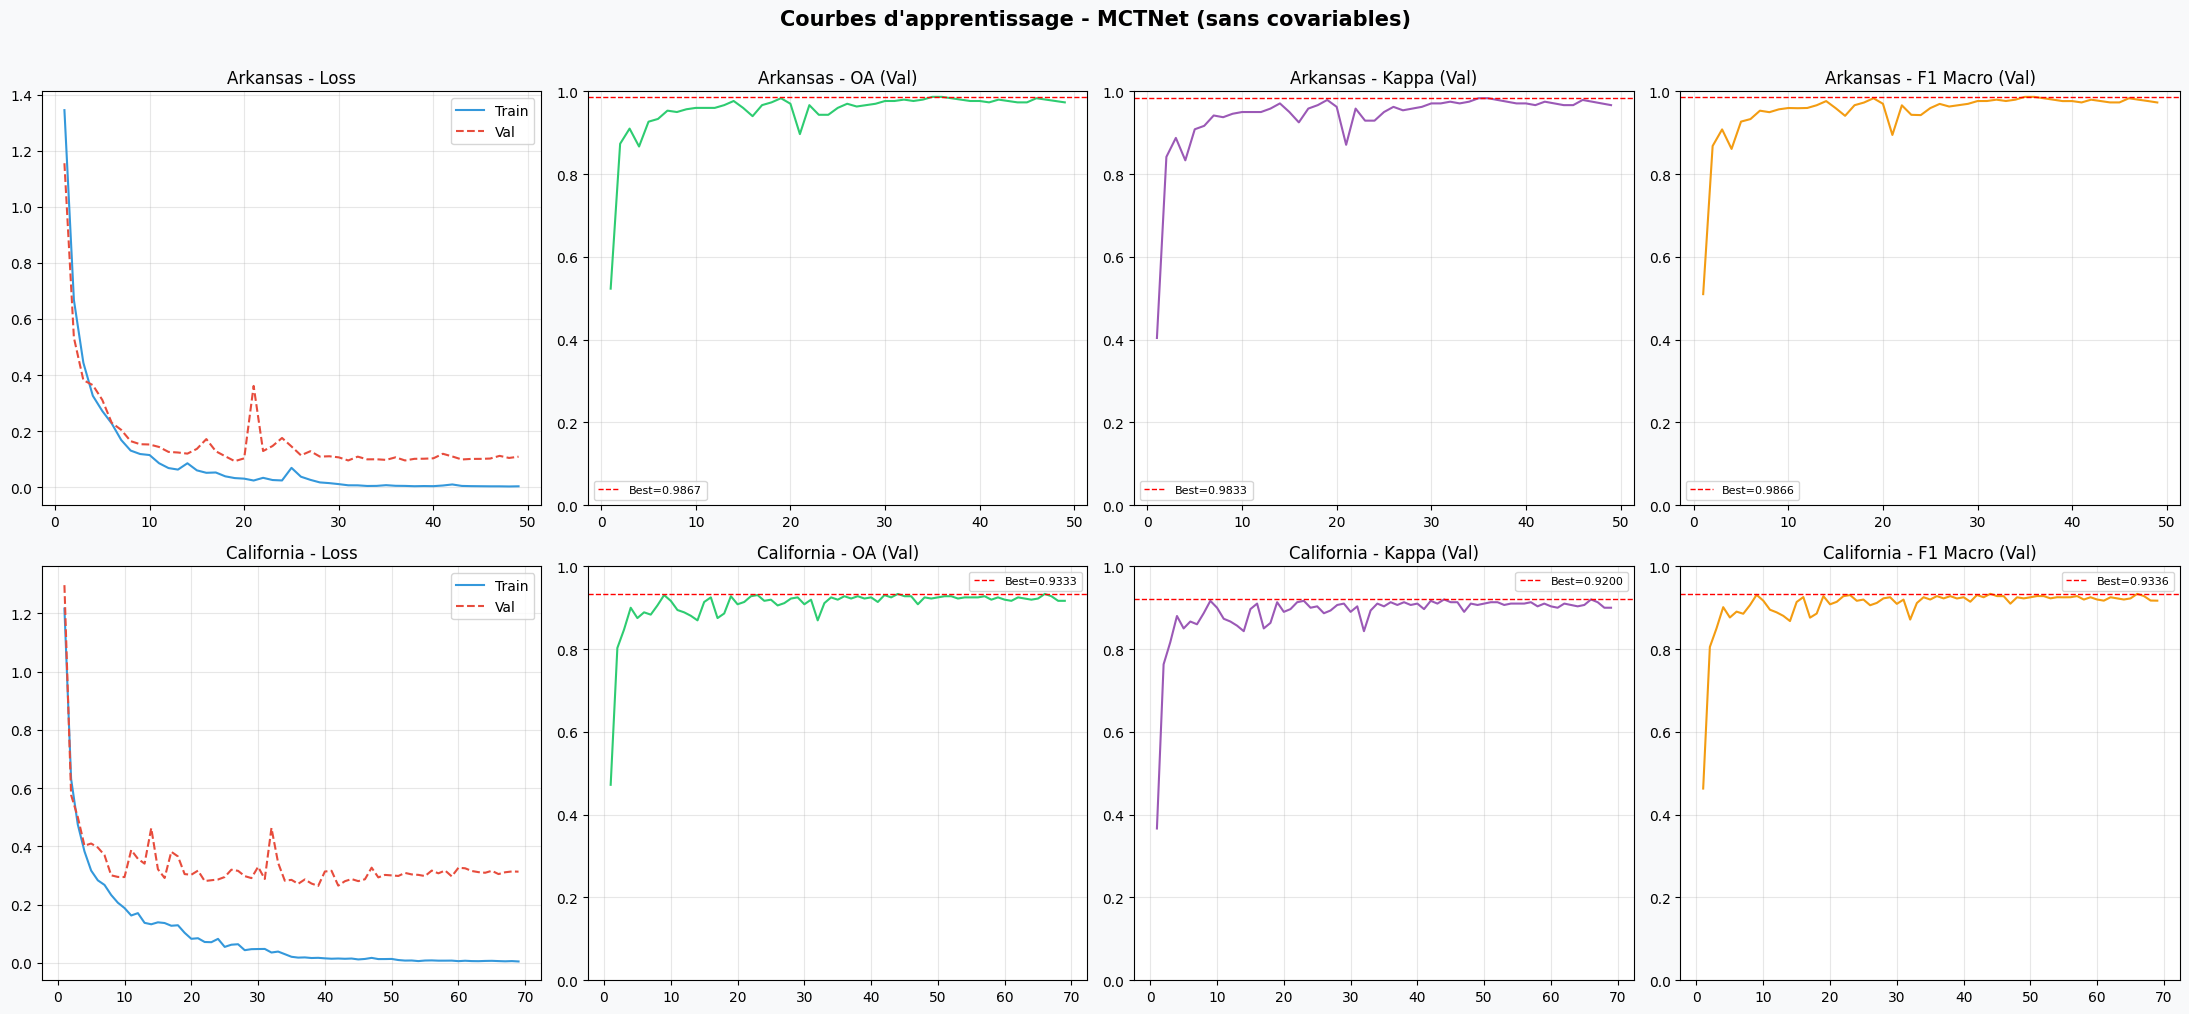

Sauvegarde : curves_no_covars.png


In [11]:
plot_curves(all_histories)

## Visualisations — Matrices de confusion

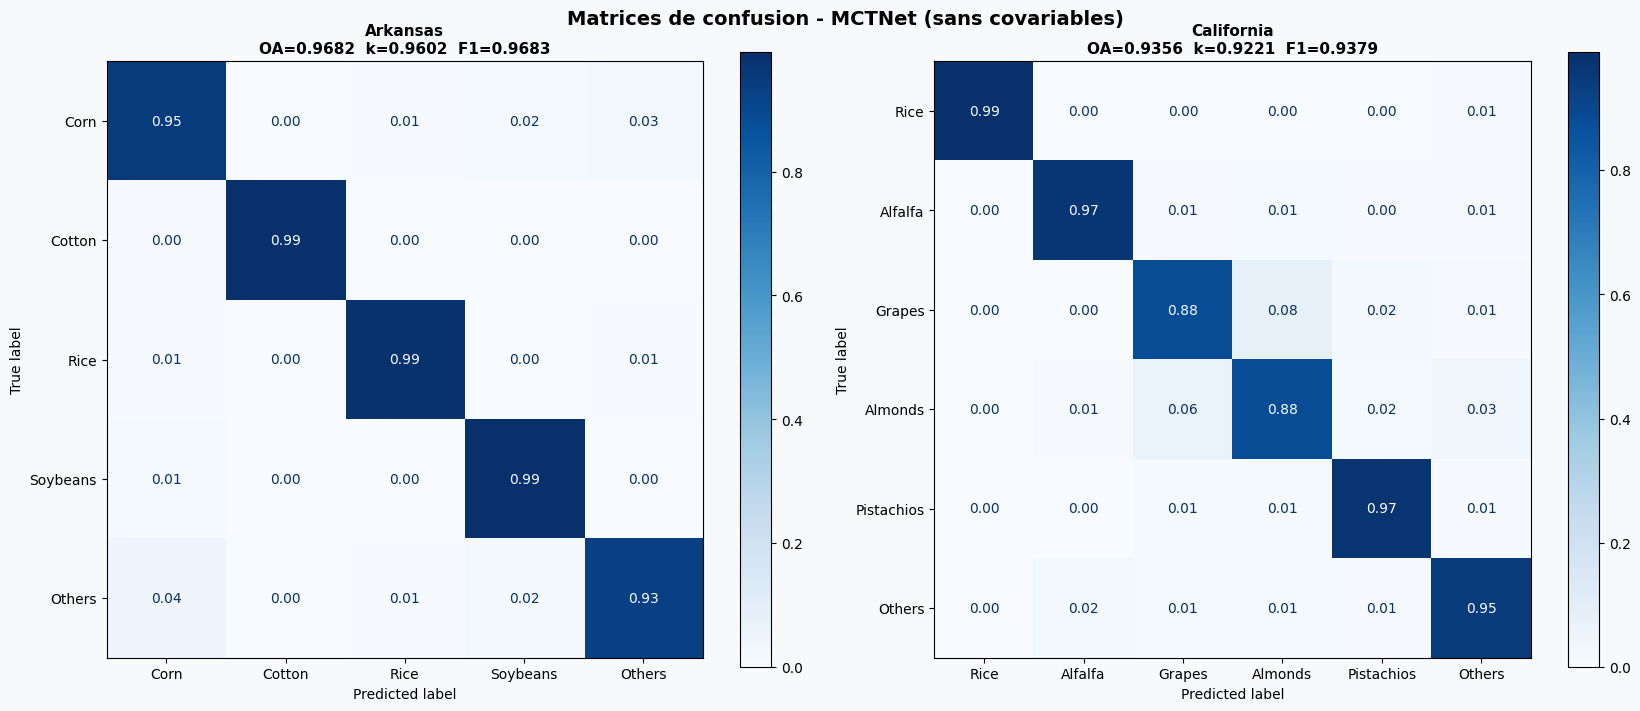

Sauvegarde : confusion_no_covars.png


In [12]:
plot_confusion(all_models, all_results, device)

## Export des résultats (CSV + Drive)

In [13]:
import csv, shutil

rows = [['Region', 'OA', 'Kappa', 'F1']]
for region in ['Arkansas', 'California']:
    r = all_results.get(region)
    if r:
        rows.append([region, f'{r["OA"]:.6f}', f'{r["Kappa"]:.6f}', f'{r["F1"]:.6f}'])

csv_path = 'results_no_covars.csv'
with open(csv_path, 'w', newline='') as f:
    csv.writer(f).writerows(rows)
print(f'CSV sauvegarde : {csv_path}')

drive_out = '/content/drive/MyDrive/data_part2/results_no_covars/'
os.makedirs(drive_out, exist_ok=True)

shutil.copy(csv_path, drive_out + csv_path)
for fname in os.listdir('.'):
    if fname.endswith('.png'):
        shutil.copy(fname, drive_out + fname)
for region, pth in all_models.items():
    if os.path.exists(pth):
        shutil.copy(pth, drive_out + os.path.basename(pth))

print(f'\nFichiers exportes vers : {drive_out}')
for f in sorted(os.listdir(drive_out)):
    print(f'  {f}')

CSV sauvegarde : results_no_covars.csv

Fichiers exportes vers : /content/drive/MyDrive/data_part2/results_no_covars/
  best_MCTNet_Arkansas_no_covars.pth
  best_MCTNet_California_no_covars.pth
  confusion_no_covars.png
  curves_no_covars.png
  results_no_covars.csv
